In [12]:
from google.colab import drive
drive.mount('/content/drive')

# path = '/content/drive/MyDrive/dataset_drink_brand_logo.rar'
# !apt-get install -qq unrar && unrar x "$path" /content/ > /dev/null

print("✅ Done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Done!


# CELL 1 — OVERVIEW

## 📌 Project Overview
This project focuses on building a Deep Learning image classification model using the **VGG16 architecture trained** for recognizing drink brand logos.

The model classifies images into 6 beverage brand categories:

- 7up
- coca
- fanta
- pepsi
- red_bull
- sprite

---

# 🎯 Objectives

- Build a professional Deep Learning pipeline using TensorFlow/Keras
- Train VGG16 architecture without pretrained weights
- Analyze training performance comprehensively
- Evaluate classification performance using multiple metrics
- Visualize predictions and model behavior professionally

---

# 📊 Dataset Summary

| Metric | Value |
|---|---|
| Total Images | 11100 |
| Train Images | 7768 |
| Validation Images | 1662 |
| Test Images | 1670 |
| Number of Classes | 6 |
| Image Size | 64x64 |

---

# 🧠 Model Configuration

- Architecture: VGG16
- Weights: None (Training from Scratch)
- Framework: TensorFlow/Keras
- Optimizer: AdamW
- Epochs: 30
- Loss Function: Categorical Crossentropy

# CELL 2 — IMPORTS & GLOBAL CONFIG

In [13]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import os
import cv2
import time
import random
import warnings
import numpy as np
import pandas as pd

from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import callbacks
from tensorflow.keras import optimizers

from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")

# ============================================
# GLOBAL CONFIG
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["font.size"] = 12

print("TensorFlow Version:", tf.__version__)

# GPU Check
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU Available:", gpus)
else:
    print("Running on CPU")

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# CELL 3 — DATA LOADING

In [14]:
# ============================================
# DATASET PATHS
# ============================================

DATASET_PATH = "/content/dataset_drink_brand_logo/classification"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

# ============================================
# CONFIG
# ============================================

IMG_SIZE = 64
BATCH_SIZE = 32
NUM_CLASSES = 6

# ============================================
# DATA GENERATORS
# ============================================

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ============================================
# LOAD DATASETS
# ============================================

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

print("\nClasses:")
print(class_names)

Found 7768 images belonging to 6 classes.
Found 1662 images belonging to 6 classes.
Found 1670 images belonging to 6 classes.

Classes:
['7up', 'coca', 'fanta', 'pepsi', 'red_bull', 'sprite']


# CELL 4 — VISUALIZE SAMPLE IMAGES

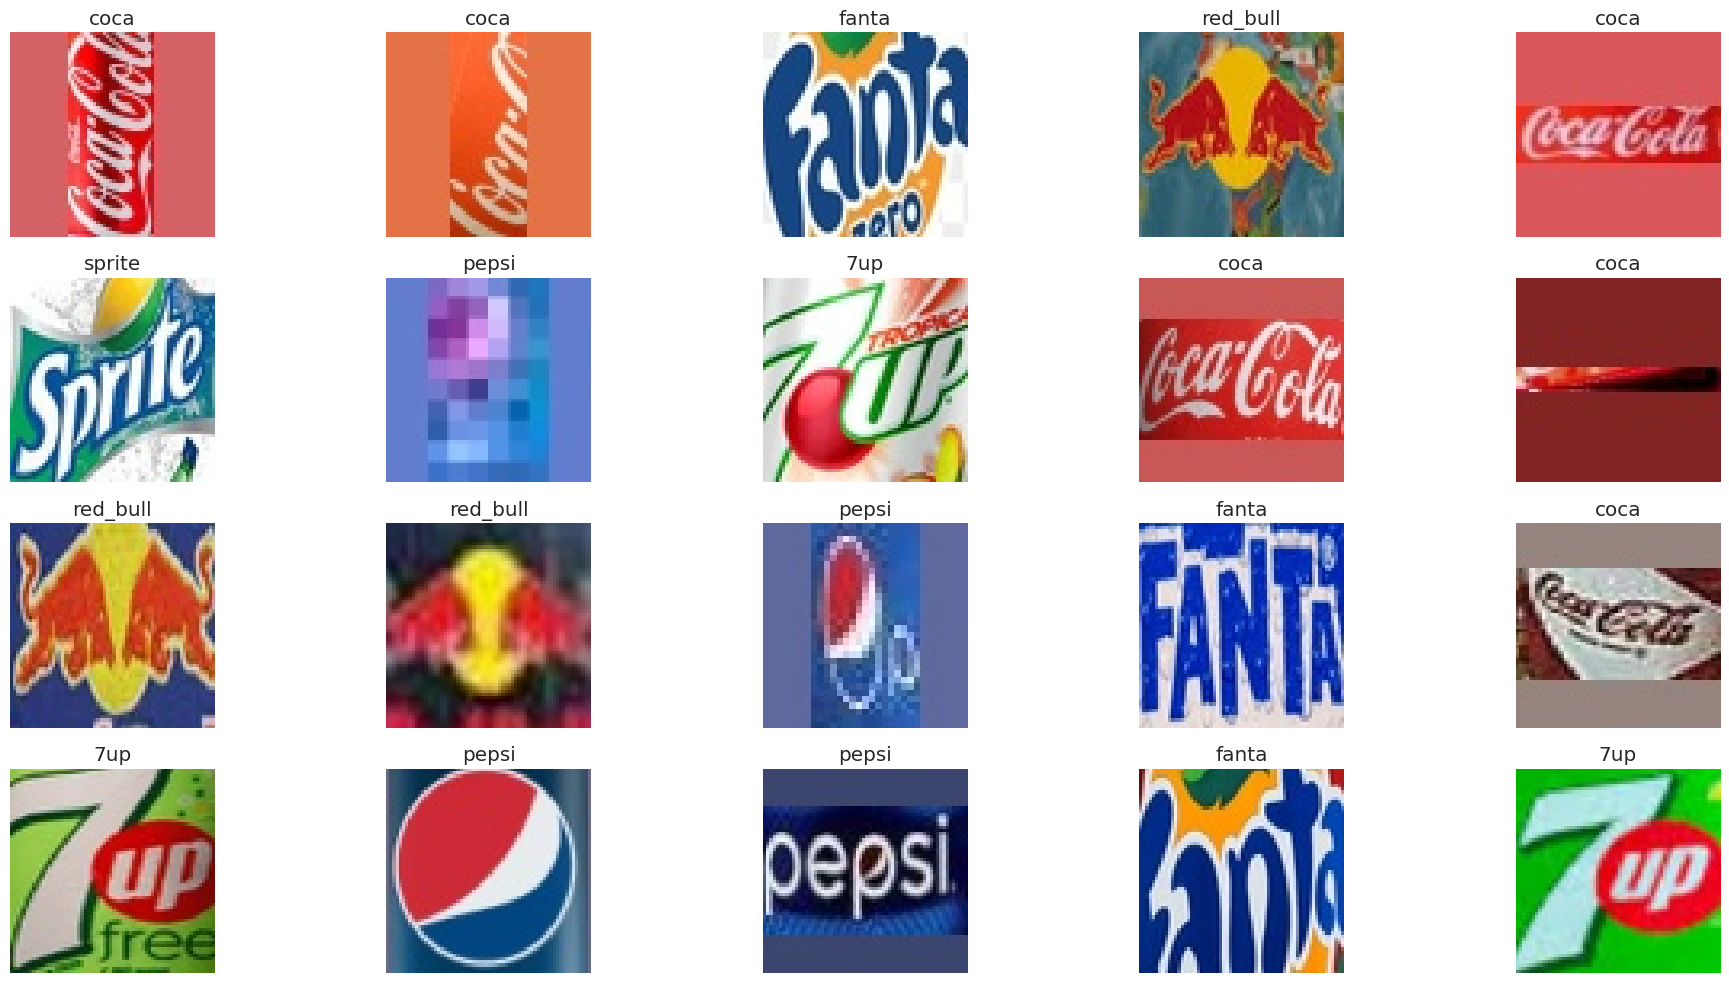

In [15]:
# ============================================
# VISUALIZE TRAINING SAMPLES
# ============================================

images, labels = next(train_generator)

plt.figure(figsize=(20,10))

for i in range(20):

    plt.subplot(4,5,i+1)

    plt.imshow(images[i])

    label = class_names[np.argmax(labels[i])]

    plt.title(label)

    plt.axis("off")

plt.tight_layout()
plt.show()

# CELL 5 — BUILD VGG16 MODEL:

In [16]:
# ============================================
# BUILD VGG16 MODEL
# ============================================

base_model = VGG16(
    weights=None,
    include_top=False,
    input_shape=(64,64,3)
)

model = models.Sequential([

    base_model,

    layers.Flatten(),

    layers.Dense(512, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')

])

# ============================================
# MODEL SUMMARY
# ============================================

model.summary()

# ============================================
# TOTAL PARAMETERS
# ============================================

total_params = model.count_params()

print(f"\nTotal Parameters: {total_params:,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,766,854 (60.15 MB)

 Trainable params: 15,766,854 (60.15 MB)

 Non-trainable params: 0 (0.00 B)


Total Parameters: 15,766,854


# CELL 6 — VISUALIZE MODEL ARCHITECTURE

In [17]:
# ============================================
# MODEL ARCHITECTURE DIAGRAM
# ============================================

try:

    plot_model(
        model,
        show_shapes=True,
        show_layer_names=True,
        expand_nested=True,
        dpi=120
    )

except:

    print("Graphviz not installed.")

# CELL 7 — COMPILE MODEL

In [18]:
# ============================================
# OPTIMIZER
# ============================================

optimizer = optimizers.AdamW(
    learning_rate=1e-4
)

# ============================================
# COMPILE MODEL
# ============================================

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


# CELL 8 — CALLBACKS

In [19]:
# ============================================
# CALLBACKS
# ============================================

checkpoint_path = "best_model_VGG16.keras"

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callback_list = [
    early_stopping,
    reduce_lr,
    model_checkpoint
]

# CELL 9 — TRAINING

In [20]:
# ============================================
# TRAINING
# ============================================

start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=callback_list
)

training_time = time.time() - start_time

print("\nTraining Completed.")

print(f"\nTotal Training Time: {training_time/60:.2f} minutes")

best_val_acc = max(history.history['val_accuracy'])

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4973 - loss: 1.2666 - precision: 0.7062 - recall: 0.3021
Epoch 1: val_loss improved from None to 0.41718, saving model to best_model_VGG16.keras

Epoch 1: finished saving model to best_model_VGG16.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - accuracy: 0.6706 - loss: 0.8878 - precision: 0.8461 - recall: 0.5430 - val_accuracy: 0.8863 - val_loss: 0.4172 - val_precision: 0.9241 - val_recall: 0.8424 - learning_rate: 1.0000e-04
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8924 - loss: 0.3733 - precision: 0.9247 - recall: 0.8555
Epoch 2: val_loss improved from 0.41718 to 0.30708, saving model to best_model_VGG16.keras

Epoch 2: finished saving model to best_model_VGG16.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.8997 - loss: 0.3420 - precision: 0.9293 - recall: 0.8696 - val_accuracy: 0.9146 - val_loss: 0.3071 - val_precision: 0.9348 - val_recall: 0.9061 - learning_rate: 1.0000e-

# CELL 10 — LEARNING CURVES

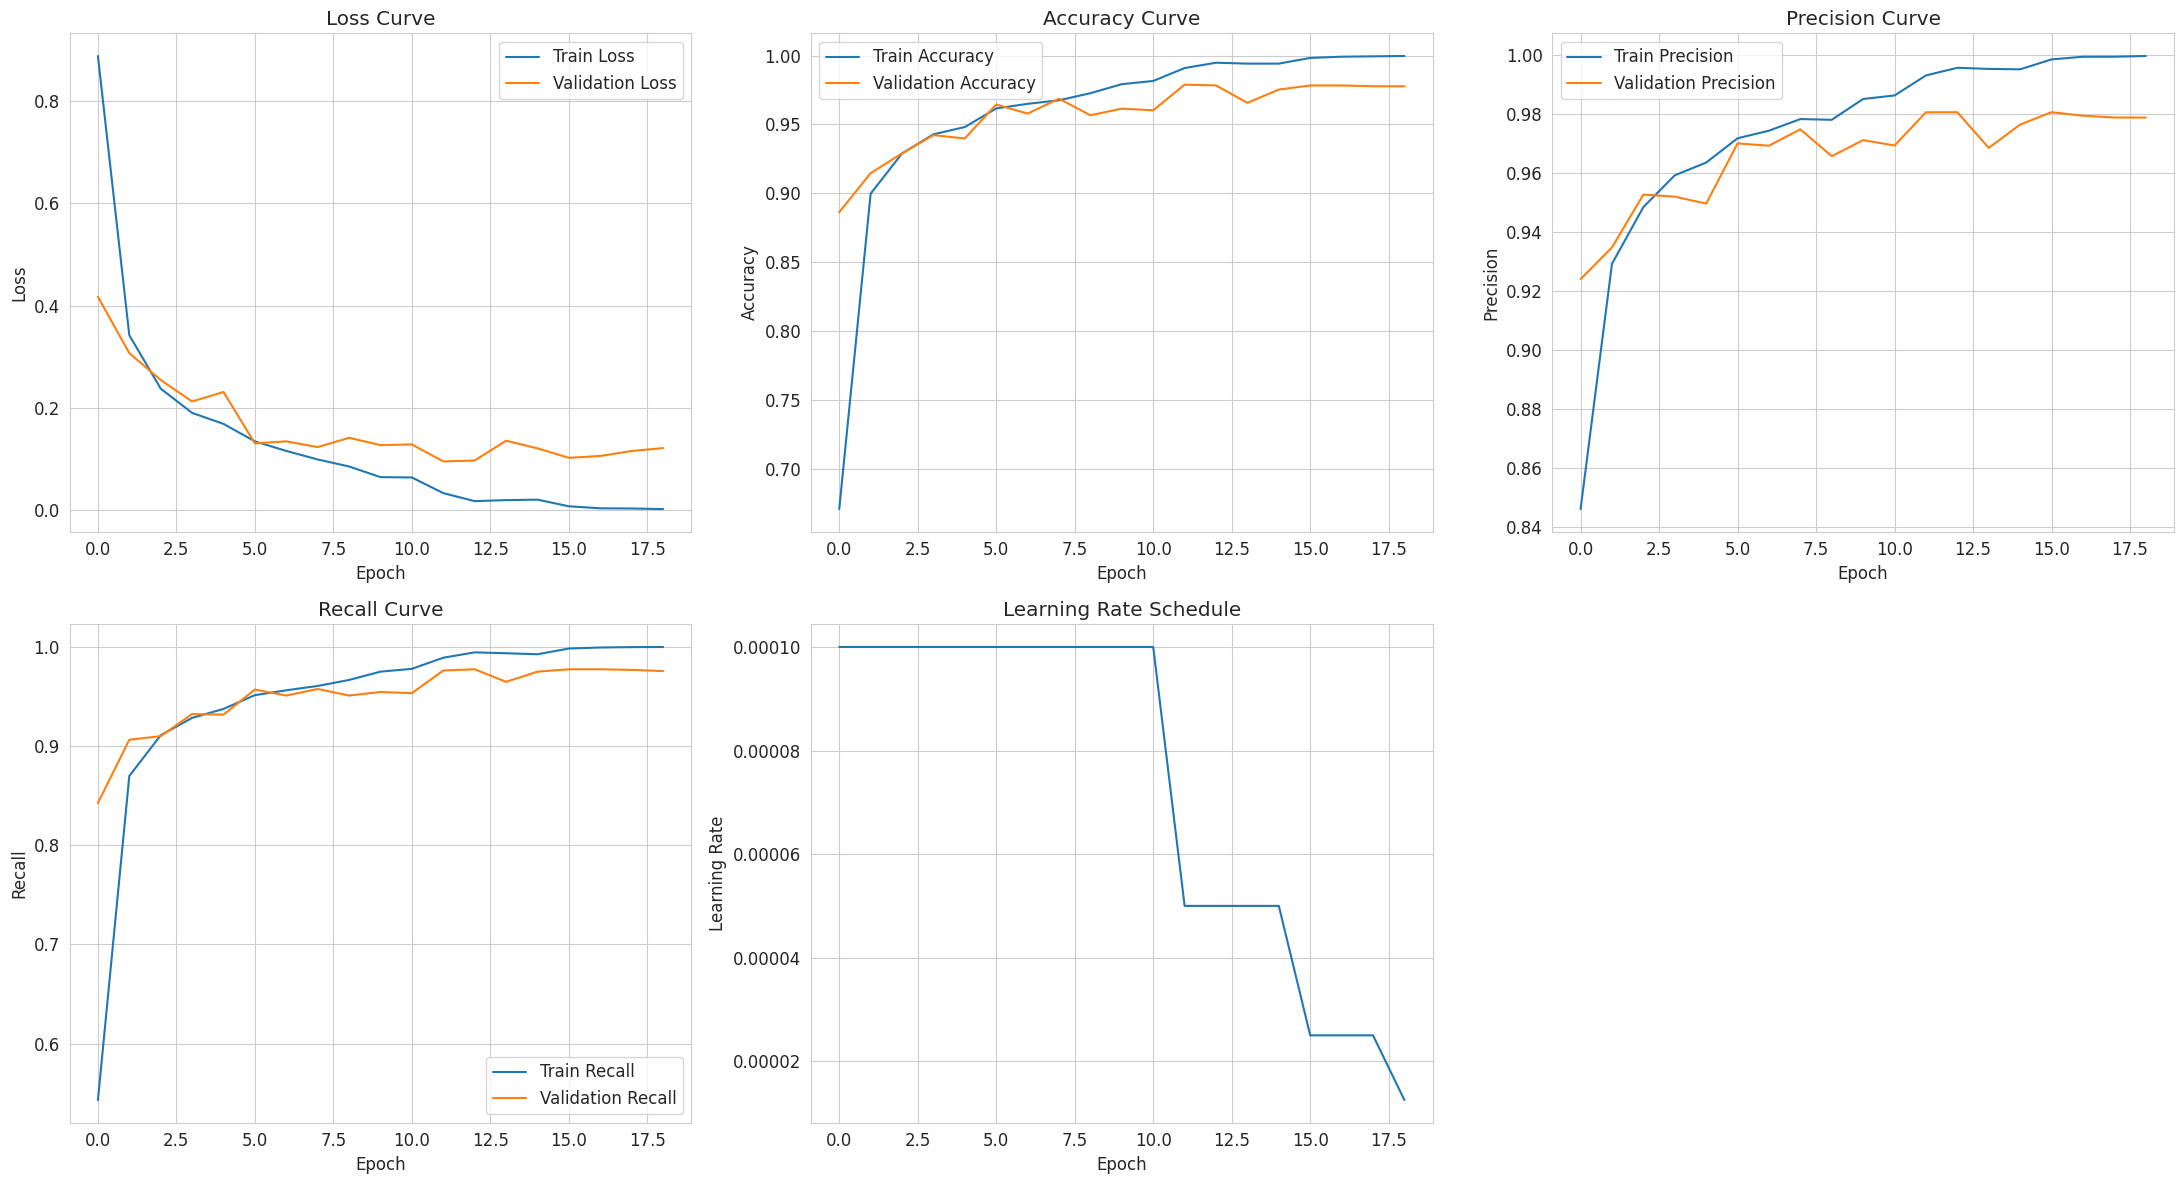

In [31]:
# ============================================
# LEARNING CURVES
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# ============================================
# LOSS CURVE
# ============================================

axes[0,0].plot(history.history['loss'], label='Train Loss')
axes[0,0].plot(history.history['val_loss'], label='Validation Loss')

axes[0,0].set_title("Loss Curve")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss")
axes[0,0].legend()
axes[0,0].grid(True)

# ============================================
# ACCURACY CURVE
# ============================================

axes[0,1].plot(history.history['accuracy'], label='Train Accuracy')
axes[0,1].plot(history.history['val_accuracy'], label='Validation Accuracy')

axes[0,1].set_title("Accuracy Curve")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Accuracy")
axes[0,1].legend()
axes[0,1].grid(True)

# ============================================
# PRECISION CURVE
# ============================================

axes[0,2].plot(history.history['precision'], label='Train Precision')
axes[0,2].plot(history.history['val_precision'], label='Validation Precision')

axes[0,2].set_title("Precision Curve")
axes[0,2].set_xlabel("Epoch")
axes[0,2].set_ylabel("Precision")
axes[0,2].legend()
axes[0,2].grid(True)

# ============================================
# RECALL CURVE
# ============================================

axes[1,0].plot(history.history['recall'], label='Train Recall')
axes[1,0].plot(history.history['val_recall'], label='Validation Recall')

axes[1,0].set_title("Recall Curve")
axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("Recall")
axes[1,0].legend()
axes[1,0].grid(True)

# ============================================
# LEARNING RATE CURVE
# ============================================

lr_key = None

if 'lr' in history.history:
    lr_key = 'lr'

elif 'learning_rate' in history.history:
    lr_key = 'learning_rate'

if lr_key is not None:

    axes[1,1].plot(history.history[lr_key])

    axes[1,1].set_title("Learning Rate Schedule")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].set_ylabel("Learning Rate")
    axes[1,1].grid(True)

else:
    axes[1,1].text(
        0.5,
        0.5,
        "Learning Rate Not Logged",
        ha='center',
        va='center',
        fontsize=14
    )

    axes[1,1].set_title("Learning Rate Schedule")
    axes[1,1].axis("off")

# ============================================
# EMPTY PLOT FOR CLEAN LAYOUT
# ============================================

axes[1,2].axis("off")

plt.tight_layout()
plt.show()

# CELL 11 — MODEL EVALUATION

In [22]:
# ============================================
# EVALUATION
# ============================================

test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)

print("\nTest Accuracy :", test_acc)
print("Test Precision:", test_precision)
print("Test Recall   :", test_recall)

# ============================================
# PREDICTIONS
# ============================================

pred_probs = model.predict(test_generator)

y_pred = np.argmax(pred_probs, axis=1)

y_true = test_generator.classes

# ============================================
# F1 SCORE
# ============================================

f1 = f1_score(y_true, y_pred, average='weighted')

print("F1 Score:", f1)

# ============================================
# CLASSIFICATION REPORT
# ============================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9695 - loss: 0.1012 - precision: 0.9741 - recall: 0.9677

Test Accuracy : 0.9694610834121704
Test Precision: 0.9740808010101318
Test Recall   : 0.9676646590232849
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
F1 Score: 0.9694913607707581
              precision    recall  f1-score   support

         7up       0.93      0.97      0.95       198
        coca       0.97      0.98      0.98       540
       fanta       0.99      0.97      0.98       221
       pepsi       0.99      0.98      0.98       361
    red_bull       0.95      0.93      0.94       180
      sprite       0.96      0.96      0.96       170

    accuracy                           0.97      1670
   macro avg       0.97      0.96      0.96      1670
weighted avg       0.97      0.97      0.97      1670



# CELL 12 — CONFUSION MATRIX ANALYTICS

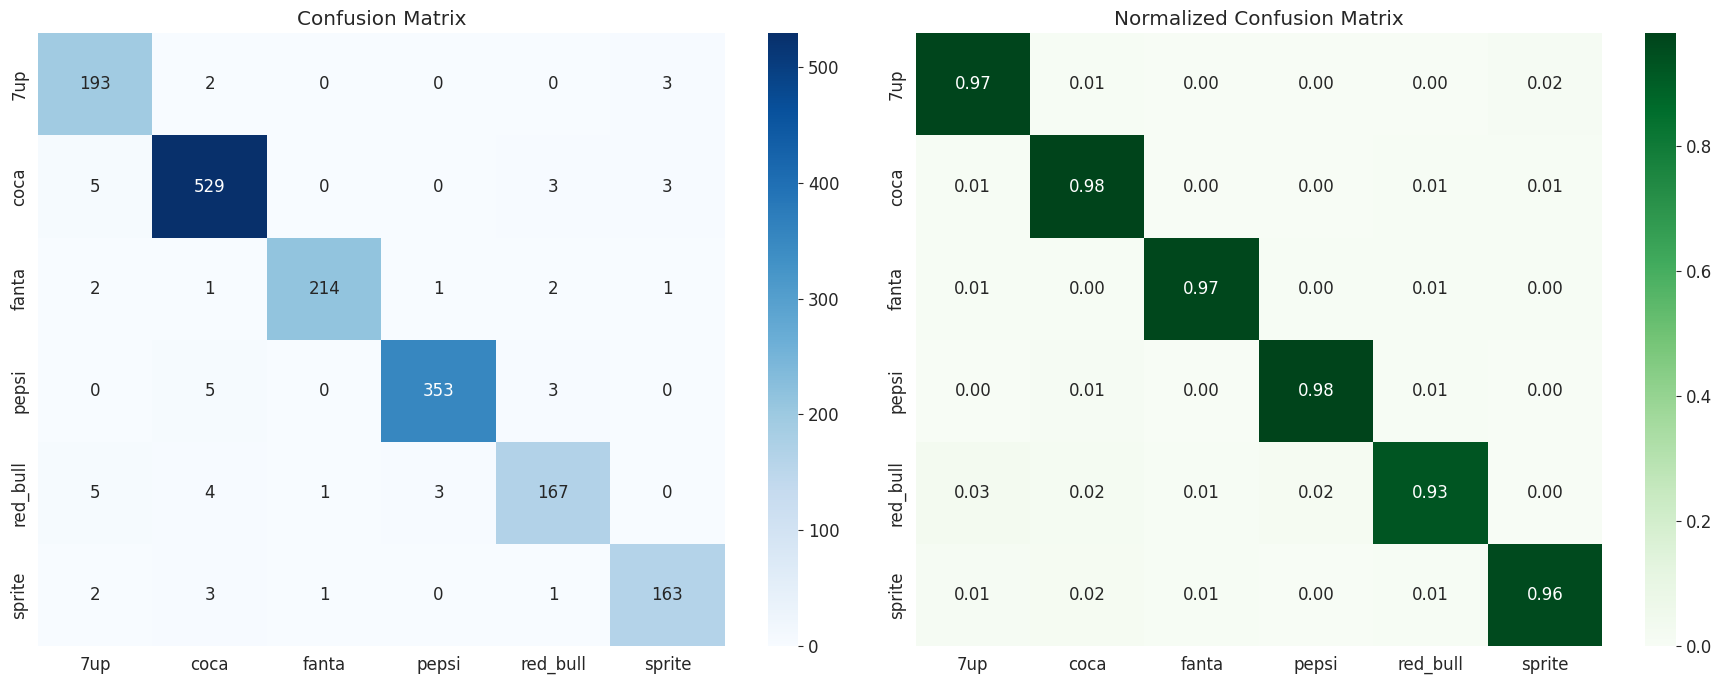

In [23]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_true, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1,2, figsize=(18,7))

# NORMAL CM
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix")

# NORMALIZED CM
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)

axes[1].set_title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

# CELL 13 — PER-CLASS ANALYTICS

In [24]:
# ============================================
# PER CLASS METRICS
# ============================================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

metrics_df = pd.DataFrame(report_dict).transpose()

metrics_df = metrics_df.iloc[:-3]

metrics_df

,precision,recall,f1-score,support
7up,0.932367,0.974747,0.953086,198.0
coca,0.972426,0.979630,0.976015,540.0
fanta,0.990741,0.968326,0.979405,221.0
pepsi,0.988796,0.977839,0.983287,361.0
red_bull,0.948864,0.927778,0.938202,180.0
sprite,0.958824,0.958824,0.958824,170.0


# CELL 14 — PER-CLASS VISUALIZATION

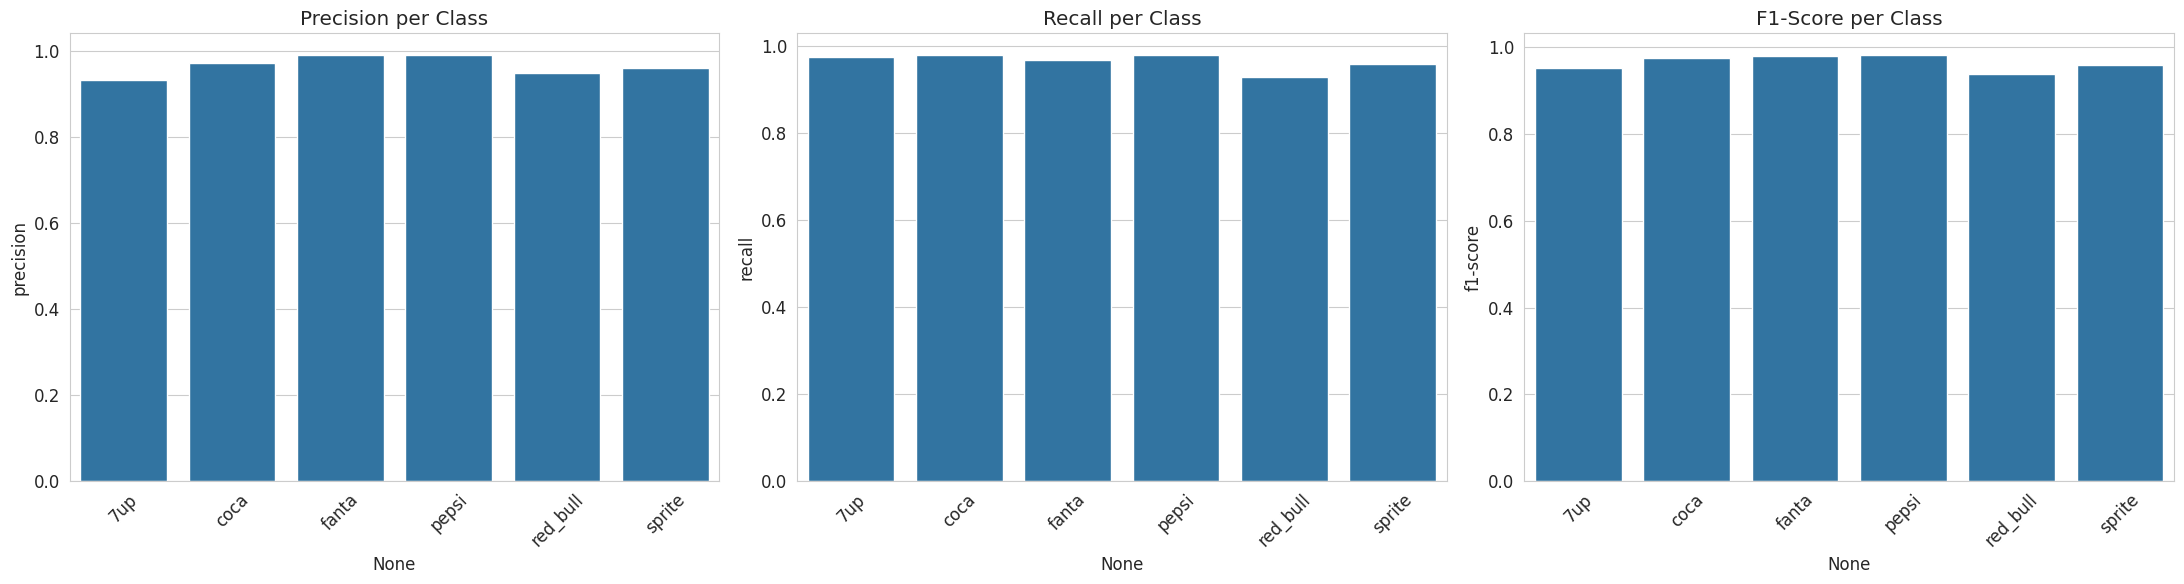

In [25]:
# ============================================
# VISUALIZE PER CLASS PERFORMANCE
# ============================================

fig, axes = plt.subplots(1,3, figsize=(22,6))

sns.barplot(
    x=metrics_df.index,
    y=metrics_df['precision'],
    ax=axes[0]
)

axes[0].set_title("Precision per Class")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    x=metrics_df.index,
    y=metrics_df['recall'],
    ax=axes[1]
)

axes[1].set_title("Recall per Class")
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(
    x=metrics_df.index,
    y=metrics_df['f1-score'],
    ax=axes[2]
)

axes[2].set_title("F1-Score per Class")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# CELL 15 — PREDICTION VISUALIZATION

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


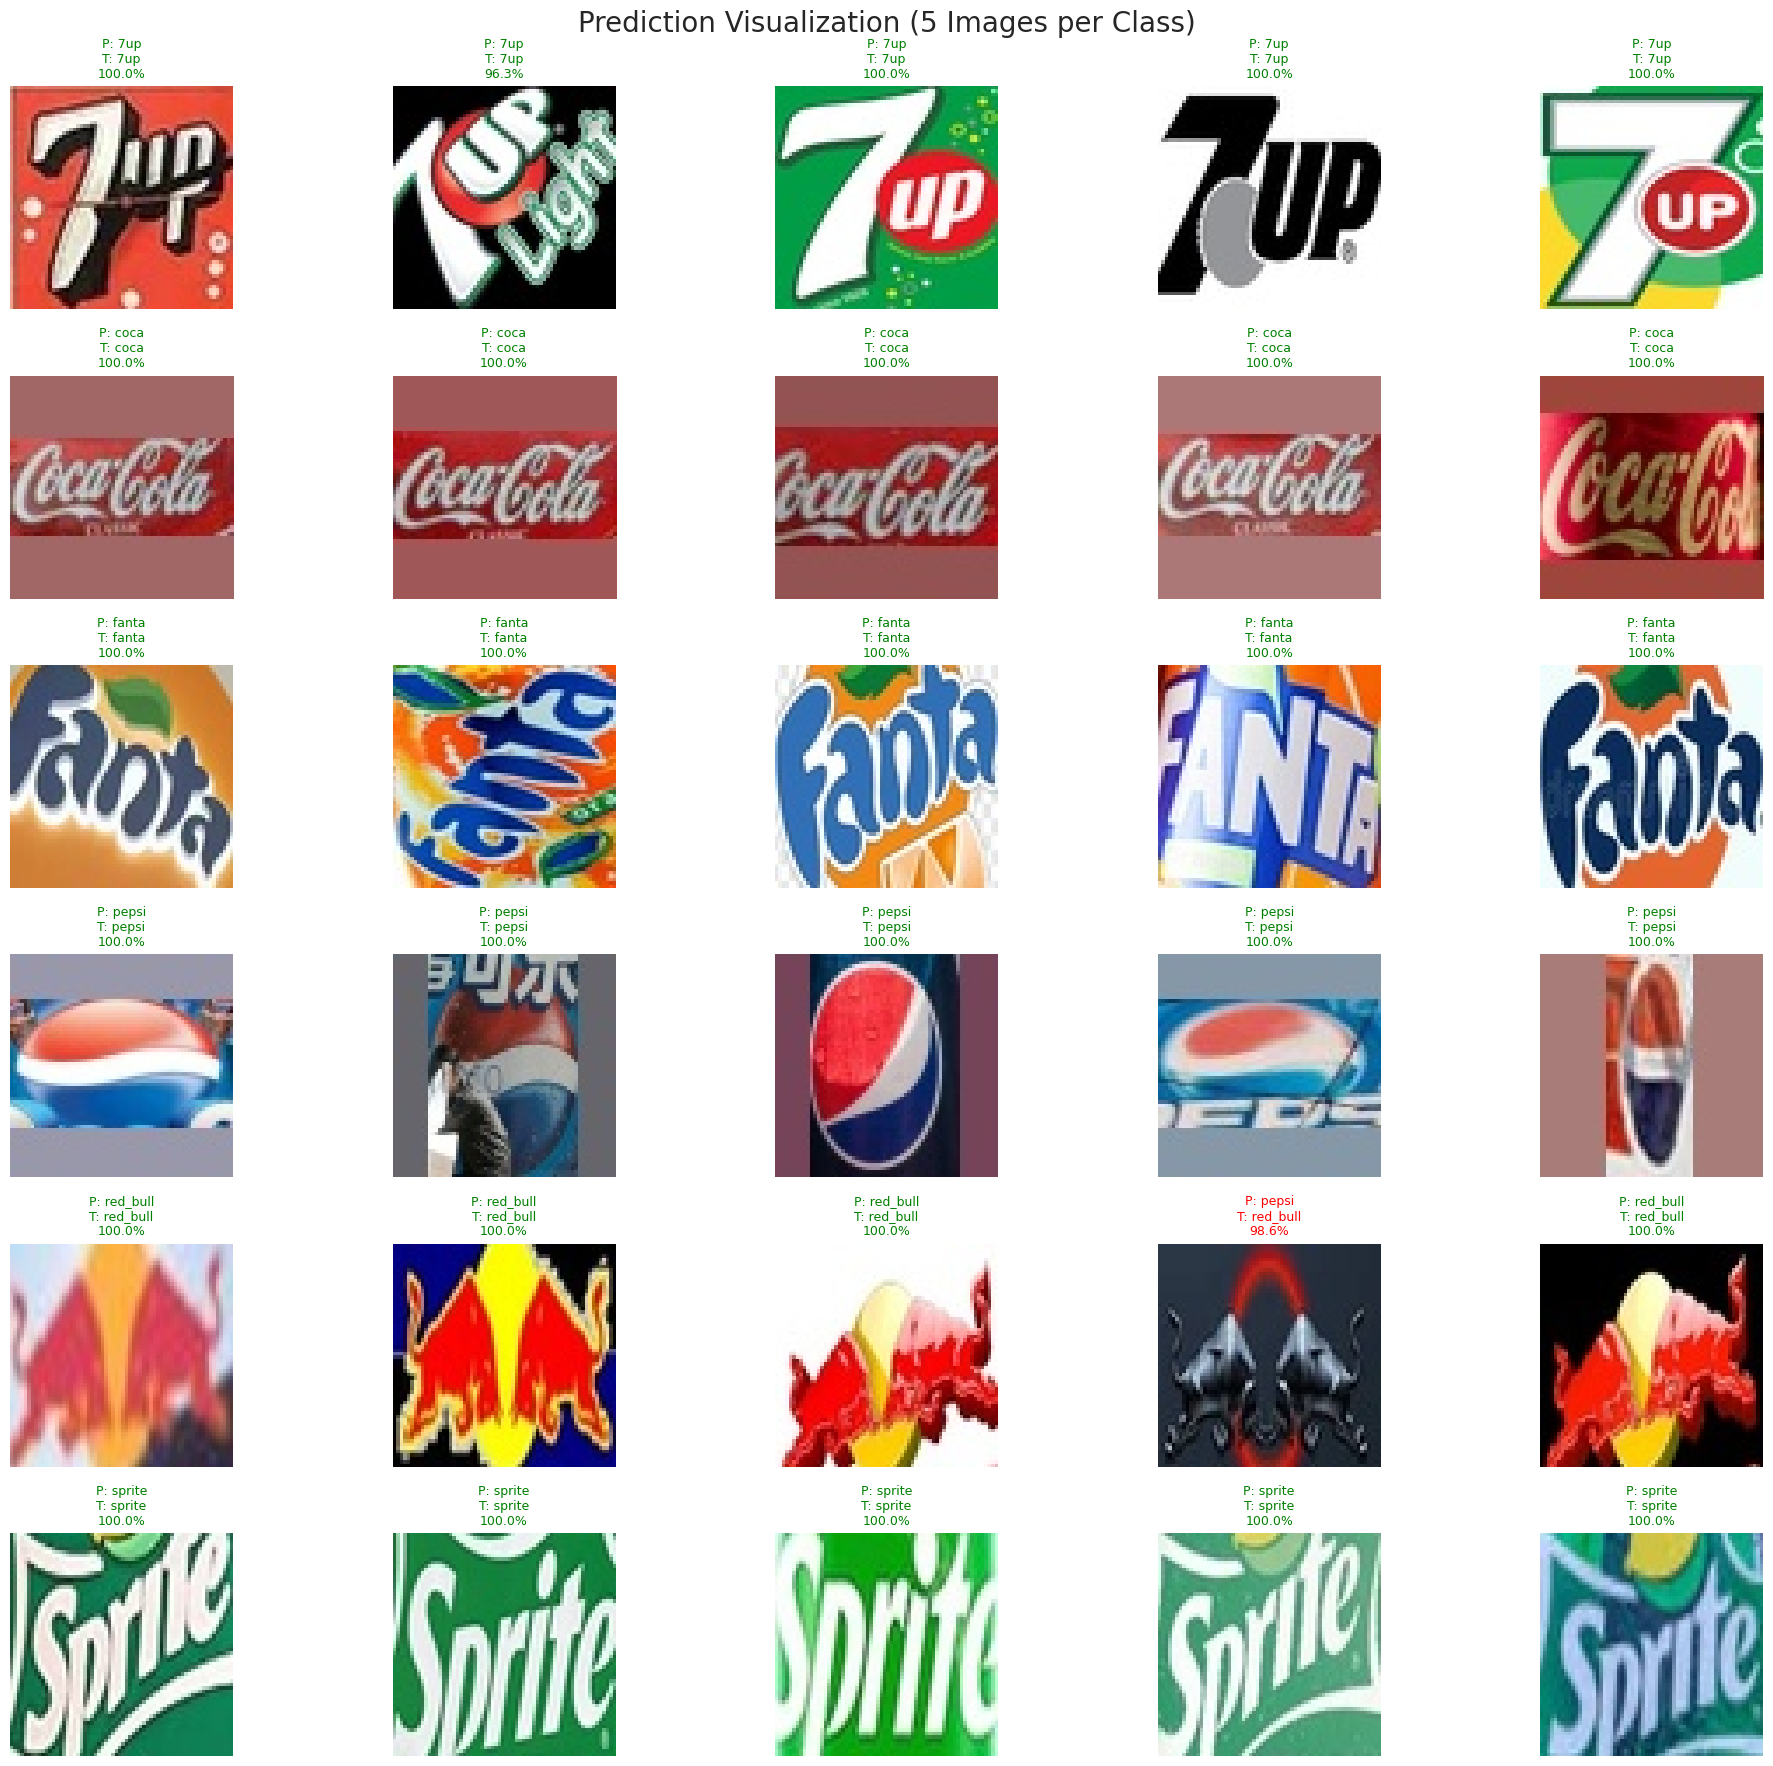

In [33]:
# ============================================
# PREDICTION VISUALIZATION
# 5 IMAGES PER CLASS
# ============================================

samples_per_class = 5

selected_images = []
selected_labels = []
selected_predictions = []

# Reset test generator
test_generator.reset()

# Predict all test set
all_predictions = model.predict(test_generator)

# All true labels
all_true_labels = test_generator.classes

# All images
all_images = []

for batch_images, batch_labels in test_generator:

    for img in batch_images:
        all_images.append(img)

    if len(all_images) >= len(all_true_labels):
        break

all_images = np.array(all_images[:len(all_true_labels)])

# ============================================
# SELECT 5 IMAGES PER CLASS
# ============================================

for class_idx in range(len(class_names)):

    class_indices = np.where(all_true_labels == class_idx)[0]

    selected_idx = class_indices[:samples_per_class]

    for idx in selected_idx:

        selected_images.append(all_images[idx])
        selected_labels.append(all_true_labels[idx])
        selected_predictions.append(all_predictions[idx])

# ============================================
# VISUALIZATION
# ============================================

total_images = len(selected_images)

rows = len(class_names)
cols = samples_per_class

plt.figure(figsize=(20, 18))

for i in range(total_images):

    plt.subplot(rows, cols, i + 1)

    plt.imshow(selected_images[i])

    pred_class = np.argmax(selected_predictions[i])
    true_class = selected_labels[i]

    confidence = np.max(selected_predictions[i]) * 100

    pred_label = class_names[pred_class]
    true_label = class_names[true_class]

    color = "green" if pred_class == true_class else "red"

    plt.title(
        f"P: {pred_label}\nT: {true_label}\n{confidence:.1f}%",
        color=color,
        fontsize=9
    )

    # Name class
    if i % cols == 0:
        plt.ylabel(
            true_label,
            fontsize=14,
            rotation=0,
            labelpad=40,
            weight='bold'
        )

    plt.axis("off")

plt.suptitle(
    "Prediction Visualization (5 Images per Class)",
    fontsize=20
)

plt.tight_layout()

plt.show()

# CELL 16 — LOAD MODEL

In [28]:
# ============================================
# LOAD BEST MODEL
# ============================================

best_model = tf.keras.models.load_model("best_model_VGG16.keras")

print("Model loaded successfully.")

Model loaded successfully.


# CELL 17 — PREDICT EXTERNAL IMAGE

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


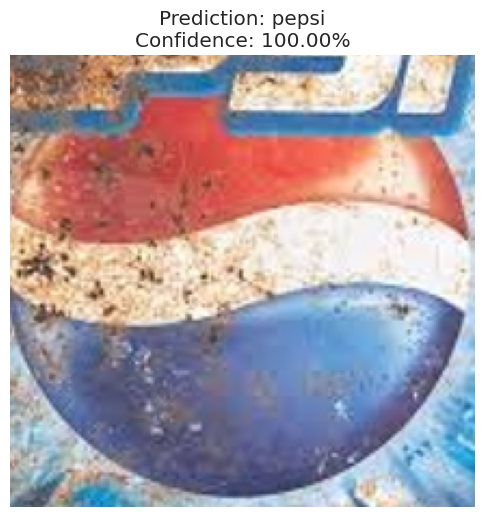

In [29]:
# ============================================
# EXTERNAL IMAGE PREDICTION
# ============================================

image_path = "/content/pepsi_00001.png"

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img_rgb, (64,64))

img_norm = img_resized / 255.0

input_img = np.expand_dims(img_norm, axis=0)

prediction = best_model.predict(input_img)

pred_class = np.argmax(prediction)

confidence = np.max(prediction) * 100

plt.figure(figsize=(6,6))

plt.imshow(img_rgb)

plt.title(
    f"Prediction: {class_names[pred_class]}\nConfidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

# CELL 18 — FINAL SUMMARY DASHBOARD

,Metric,Value
0,Best Validation Accuracy,0.9789
1,Test Accuracy,0.9695
2,Test Precision,0.9741
3,Test Recall,0.9677
4,F1 Score,0.9695
5,Total Parameters,"15,766,854"
6,Epochs,19
7,Training Time (min),7.03


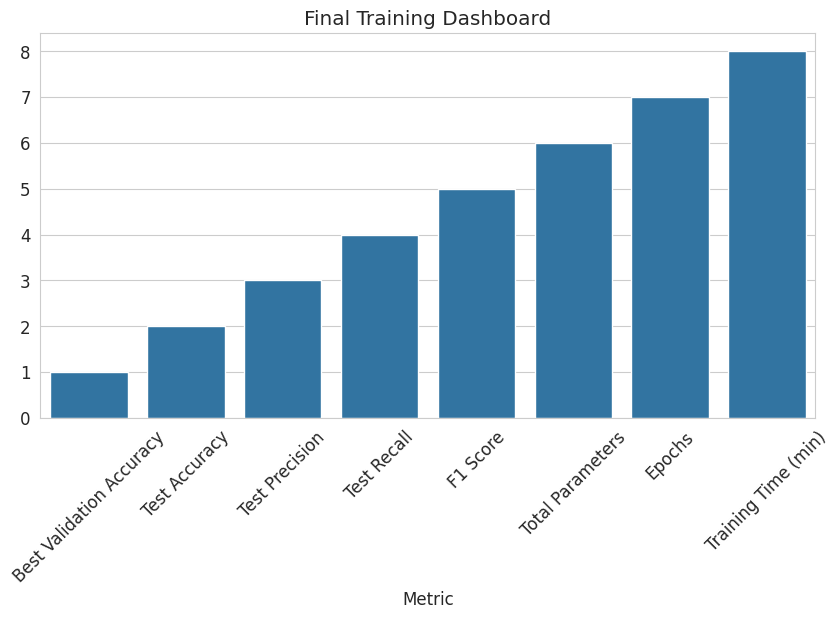

In [30]:
# ============================================
# FINAL DASHBOARD
# ============================================

summary_data = {

    "Metric": [
        "Best Validation Accuracy",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "F1 Score",
        "Total Parameters",
        "Epochs",
        "Training Time (min)"
    ],

    "Value": [
        round(best_val_acc,4),
        round(test_acc,4),
        round(test_precision,4),
        round(test_recall,4),
        round(f1,4),
        f"{total_params:,}",
        len(history.history['loss']),
        round(training_time/60,2)
    ]
}

summary_df = pd.DataFrame(summary_data)

display(summary_df)

# ============================================
# VISUAL SUMMARY
# ============================================

plt.figure(figsize=(10,5))

sns.barplot(
    x="Metric",
    y=[1,2,3,4,5,6,7,8],
    data=summary_df
)

plt.xticks(rotation=45)

plt.title("Final Training Dashboard")

plt.show()